In [36]:
import pandas as pd
import numpy as np
import re
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("ambient-weather-April_2023.csv")

df.head()


Saving ambient-weather-April_2023.csv to ambient-weather-April_2023 (1).csv


,Date,Simple Date,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),...,Daily Rain (mm),Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec)
0,2023-05-01T23:55:00+05:30,2023-05-01 23:55:00,24.6,25.6,23.6,0.0,0.0,7.1,237,0.0,...,3.3,3.3,3.3,1134.7,94,0,0.0,1,244,0.0
1,2023-05-01T23:50:00+05:30,2023-05-01 23:50:00,24.7,25.7,23.7,0.0,0.0,7.1,268,1.2,...,3.3,3.3,3.3,1134.7,94,0,0.0,1,244,0.0
2,2023-05-01T23:45:00+05:30,2023-05-01 23:45:00,24.7,25.7,23.7,0.2,1.0,7.1,235,1.2,...,3.3,3.3,3.3,1134.7,94,0,0.0,1,260,0.5
3,2023-05-01T23:40:00+05:30,2023-05-01 23:40:00,24.8,25.8,23.7,0.3,1.0,7.1,260,0.0,...,3.1,3.1,3.1,1134.5,94,0,0.0,1,260,0.5
4,2023-05-01T23:35:00+05:30,2023-05-01 23:35:00,24.9,25.9,23.9,0.8,1.0,7.1,258,0.0,...,3.1,3.1,3.1,1134.5,94,0,0.0,1,278,0.6


In [37]:
import pandas as pd

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Check if any negative value exists
has_negative = (numeric_df < 0).any().any()

print("Negative values present:", has_negative)


Negative values present: False


In [38]:
df.columns


Index(['Date', 'Simple Date', 'Outdoor Temperature (°C)', 'Feels Like (°C)',
       'Dew Point (°C)', 'Wind Speed (m/sec)', 'Wind Gust (m/sec)',
       'Max Daily Gust (m/sec)', 'Wind Direction (°)', 'Hourly Rain (mm/hr)',
       'Event Rain (mm)', 'Daily Rain (mm)', 'Weekly Rain (mm)',
       'Monthly Rain (mm)', 'Yearly Rain (mm)', 'Humidity (%)',
       'Ultra-Violet Radiation Index', 'Solar Radiation (W/m^2)',
       'Outdoor Battery', 'Avg Wind Direction (10 mins) (°)',
       'Avg Wind Speed (10 mins) (m/sec)'],
      dtype='object')

In [39]:
def clean_date(date_str):
    if pd.isna(date_str):
        return np.nan

    # Remove timezone info like +05:30
    date_str = re.sub(r"\+\d{2}:\d{2}", "", str(date_str))

    # Replace 'T' with space
    date_str = date_str.replace("T", " ")

    return date_str.strip()

In [40]:
df["Clean_Date"] = df["Date"].apply(clean_date)
df[["Date", "Clean_Date"]].head()


,Date,Clean_Date
0,2023-05-01T23:55:00+05:30,2023-05-01 23:55:00
1,2023-05-01T23:50:00+05:30,2023-05-01 23:50:00
2,2023-05-01T23:45:00+05:30,2023-05-01 23:45:00
3,2023-05-01T23:40:00+05:30,2023-05-01 23:40:00
4,2023-05-01T23:35:00+05:30,2023-05-01 23:35:00


In [41]:
df["Datetime"] = pd.to_datetime(
    df["Clean_Date"],
    errors="coerce",
    infer_datetime_format=True
)

df["Datetime"].isna().sum()


/tmp/ipython-input-3282131910.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["Datetime"] = pd.to_datetime(


np.int64(0)

In [42]:
df["Datetime"] = df["Datetime"].ffill().bfill()


In [43]:
df = df.set_index("Datetime").sort_index()
df.head()


,Date,Simple Date,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),...,Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec),Clean_Date
Datetime,,,,,,,,,,,,,,,,,,,,,
2023-04-01 00:00:00,2023-04-01T00:00:00+05:30,2023-04-01 00:00:00,27.3,30.3,23.3,0.6,2.0,2.0,153,0.0,...,1.0,0.0,1093.1,79,0,0.0,1,157,0.6,2023-04-01 00:00:00
2023-04-01 00:05:00,2023-04-01T00:05:00+05:30,2023-04-01 00:05:00,27.3,30.1,23.1,1.1,2.0,2.6,120,0.0,...,1.0,0.0,1093.1,78,0,0.0,1,94,0.9,2023-04-01 00:05:00
2023-04-01 00:10:00,2023-04-01T00:10:00+05:30,2023-04-01 00:10:00,27.4,30.4,23.2,0.9,1.5,2.6,143,0.0,...,1.0,0.0,1093.1,78,0,0.0,1,103,0.7,2023-04-01 00:10:00
2023-04-01 00:15:00,2023-04-01T00:15:00+05:30,2023-04-01 00:15:00,27.4,30.4,23.2,1.3,2.0,2.6,118,0.0,...,1.0,0.0,1093.1,78,0,0.0,1,97,0.7,2023-04-01 00:15:00
2023-04-01 00:20:00,2023-04-01T00:20:00+05:30,2023-04-01 00:20:00,27.3,30.1,23.1,1.1,1.5,2.6,104,0.0,...,1.0,0.0,1093.1,78,0,0.0,1,123,0.8,2023-04-01 00:20:00


In [44]:
hourly_df = df.resample("H").mean(numeric_only=True)
hourly_df.head()


/tmp/ipython-input-3403959349.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.resample("H").mean(numeric_only=True)


,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),Event Rain (mm),Daily Rain (mm),Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec)
Datetime,,,,,,,,,,,,,,,,,,,
2023-04-01 00:00:00,27.291667,30.150000,23.150000,0.716667,1.333333,2.55,142.833333,0.0,0.0,0.0,1.0,0.0,1093.1,78.250000,0.0,0.0,1.0,140.833333,0.675000
2023-04-01 01:00:00,26.966667,29.675000,23.233333,0.625000,0.916667,2.60,141.416667,0.0,0.0,0.0,1.0,0.0,1093.1,80.250000,0.0,0.0,1.0,147.666667,0.491667
2023-04-01 02:00:00,26.891667,29.566667,23.325000,0.291667,0.708333,2.60,169.500000,0.0,0.0,0.0,1.0,0.0,1093.1,81.083333,0.0,0.0,1.0,159.916667,0.475000
2023-04-01 03:00:00,26.941667,29.583333,23.125000,0.416667,0.791667,2.60,167.416667,0.0,0.0,0.0,1.0,0.0,1093.1,79.916667,0.0,0.0,1.0,171.916667,0.450000
2023-04-01 04:00:00,26.841667,29.250000,22.766667,0.333333,0.625000,2.60,193.083333,0.0,0.0,0.0,1.0,0.0,1093.1,78.583333,0.0,0.0,1.0,186.083333,0.316667


In [45]:
full_hours = pd.date_range(
    start=hourly_df.index.min(),
    end=hourly_df.index.max(),
    freq="h"
)

hourly_df = hourly_df.reindex(full_hours)


In [46]:
hourly_df.head()


,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),Event Rain (mm),Daily Rain (mm),Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec)
2023-04-01 00:00:00,27.291667,30.150000,23.150000,0.716667,1.333333,2.55,142.833333,0.0,0.0,0.0,1.0,0.0,1093.1,78.250000,0.0,0.0,1.0,140.833333,0.675000
2023-04-01 01:00:00,26.966667,29.675000,23.233333,0.625000,0.916667,2.60,141.416667,0.0,0.0,0.0,1.0,0.0,1093.1,80.250000,0.0,0.0,1.0,147.666667,0.491667
2023-04-01 02:00:00,26.891667,29.566667,23.325000,0.291667,0.708333,2.60,169.500000,0.0,0.0,0.0,1.0,0.0,1093.1,81.083333,0.0,0.0,1.0,159.916667,0.475000
2023-04-01 03:00:00,26.941667,29.583333,23.125000,0.416667,0.791667,2.60,167.416667,0.0,0.0,0.0,1.0,0.0,1093.1,79.916667,0.0,0.0,1.0,171.916667,0.450000
2023-04-01 04:00:00,26.841667,29.250000,22.766667,0.333333,0.625000,2.60,193.083333,0.0,0.0,0.0,1.0,0.0,1093.1,78.583333,0.0,0.0,1.0,186.083333,0.316667


In [47]:
hourly_df = hourly_df.interpolate(method="time")


In [48]:
hourly_df = hourly_df.reset_index()
hourly_df.rename(columns={"index": "Datetime"}, inplace=True)

hourly_df.head()


,Datetime,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),Event Rain (mm),Daily Rain (mm),Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec)
0,2023-04-01 00:00:00,27.291667,30.150000,23.150000,0.716667,1.333333,2.55,142.833333,0.0,0.0,0.0,1.0,0.0,1093.1,78.250000,0.0,0.0,1.0,140.833333,0.675000
1,2023-04-01 01:00:00,26.966667,29.675000,23.233333,0.625000,0.916667,2.60,141.416667,0.0,0.0,0.0,1.0,0.0,1093.1,80.250000,0.0,0.0,1.0,147.666667,0.491667
2,2023-04-01 02:00:00,26.891667,29.566667,23.325000,0.291667,0.708333,2.60,169.500000,0.0,0.0,0.0,1.0,0.0,1093.1,81.083333,0.0,0.0,1.0,159.916667,0.475000
3,2023-04-01 03:00:00,26.941667,29.583333,23.125000,0.416667,0.791667,2.60,167.416667,0.0,0.0,0.0,1.0,0.0,1093.1,79.916667,0.0,0.0,1.0,171.916667,0.450000
4,2023-04-01 04:00:00,26.841667,29.250000,22.766667,0.333333,0.625000,2.60,193.083333,0.0,0.0,0.0,1.0,0.0,1093.1,78.583333,0.0,0.0,1.0,186.083333,0.316667


In [49]:
hourly_df.to_csv(
    "cleaned_april_weather.csv",
    index=False,
    float_format="%.2f"
)





In [50]:
from google.colab import files
files.download("cleaned_april_weather.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv(
    "/content/drive/MyDrive/team_lambda/cleaned_april_weather.csv",
    index=False
)
print("Cleaned CSV saved to Google Drive")

Mounted at /content/drive
Cleaned CSV saved to Google Drive


In [17]:
hourly_df["Datetime"].head()


,Datetime
0,2023-04-01 00:00:00
1,2023-04-01 01:00:00
2,2023-04-01 02:00:00
3,2023-04-01 03:00:00
4,2023-04-01 04:00:00


In [18]:
# Check for duplicate timestamps
hourly_df.duplicated(subset=["Datetime"]).sum()

np.int64(0)

In [19]:
hourly_df.describe()


,Datetime,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),Event Rain (mm),Daily Rain (mm),Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec)
count,744,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.0,744.000000,744.000000
mean,2023-04-16 11:29:59.999999744,29.874082,32.843672,21.915983,0.779503,1.560249,4.145284,176.822357,0.050067,1.530141,0.387735,2.174832,10.310316,1104.645800,65.548275,1.710909,199.955063,1.0,175.151770,0.769142
min,2023-04-01 00:00:00,22.233333,22.350000,12.475000,0.000000,0.000000,0.375000,80.333333,0.000000,0.000000,0.000000,0.000000,0.000000,1093.100000,21.666667,0.000000,0.000000,1.0,52.083333,0.000000
25%,2023-04-08 17:45:00,26.483333,27.556250,20.677083,0.314583,0.708333,2.462500,140.416667,0.000000,0.000000,0.000000,0.000000,1.000000,1094.100000,52.375000,0.000000,0.000000,1.0,140.395833,0.308333
50%,2023-04-16 11:30:00,28.950000,32.654167,23.033333,0.758333,1.466667,3.808333,166.916667,0.000000,0.000000,0.000000,0.000000,1.000000,1094.100000,68.916667,0.000000,7.175000,1.0,168.375000,0.758333
75%,2023-04-24 05:15:00,33.558333,37.283333,23.852083,1.177083,2.341667,5.600000,215.875000,0.000000,0.000000,0.000000,1.800000,28.700000,1126.400000,80.166667,3.687500,427.185417,1.0,216.166667,1.158333
max,2023-05-01 23:00:00,39.233333,45.683333,25.266667,2.866667,6.516667,11.200000,281.833333,18.650000,20.800000,20.800000,27.700000,38.300000,1134.550000,93.583333,7.416667,816.650000,1.0,278.583333,2.958333
std,NaN,4.138902,5.495528,2.744240,0.542876,1.027930,2.241283,44.316044,0.745613,4.311956,2.246768,4.629844,14.557753,15.293359,17.849547,2.387312,264.612883,0.0,45.321178,0.535723


In [20]:
#missing values
hourly_df.isna().sum()


,0
Datetime,0
Outdoor Temperature (°C),0
Feels Like (°C),0
Dew Point (°C),0
Wind Speed (m/sec),0
Wind Gust (m/sec),0
Max Daily Gust (m/sec),0
Wind Direction (°),0
Hourly Rain (mm/hr),0
Event Rain (mm),0


In [21]:
# hourly_df["hour"] = hourly_df["Datetime"].dt.hour
# hourly_df["day"] = hourly_df["Datetime"].dt.day
# hourly_df["month"] = hourly_df["Datetime"].dt.month
# hourly_df["day_of_week"] = hourly_df["Datetime"].dt.dayofweek


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
plt.style.use("seaborn-v0_8")
sns.set_context("talk")

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/team_lambda/cleaned_hourly_april1.csv"
)



# Convert datetime column (adjust name if needed)
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Set datetime as index
df = df.set_index("Datetime")

df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),Event Rain (mm),Daily Rain (mm),Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec)
Datetime,,,,,,,,,,,,,,,,,,,
2023-04-01 00:00:00,27.29,30.15,23.15,0.72,1.33,2.55,142.83,0.0,0.0,0.0,1.0,0.0,1093.1,78.25,0.0,0.0,1.0,140.83,0.67
2023-04-01 01:00:00,26.97,29.68,23.23,0.62,0.92,2.60,141.42,0.0,0.0,0.0,1.0,0.0,1093.1,80.25,0.0,0.0,1.0,147.67,0.49
2023-04-01 02:00:00,26.89,29.57,23.32,0.29,0.71,2.60,169.50,0.0,0.0,0.0,1.0,0.0,1093.1,81.08,0.0,0.0,1.0,159.92,0.48
2023-04-01 03:00:00,26.94,29.58,23.12,0.42,0.79,2.60,167.42,0.0,0.0,0.0,1.0,0.0,1093.1,79.92,0.0,0.0,1.0,171.92,0.45
2023-04-01 04:00:00,26.84,29.25,22.77,0.33,0.62,2.60,193.08,0.0,0.0,0.0,1.0,0.0,1093.1,78.58,0.0,0.0,1.0,186.08,0.32


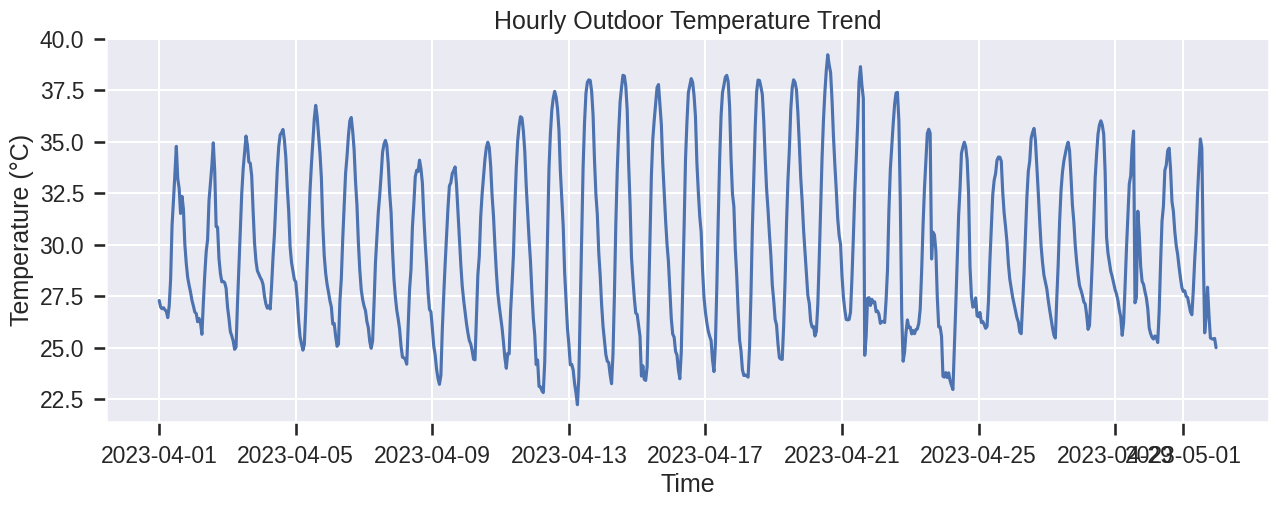

In [23]:
#Outdoor Temperature
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Outdoor Temperature (°C)"])
plt.title("Hourly Outdoor Temperature Trend")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()



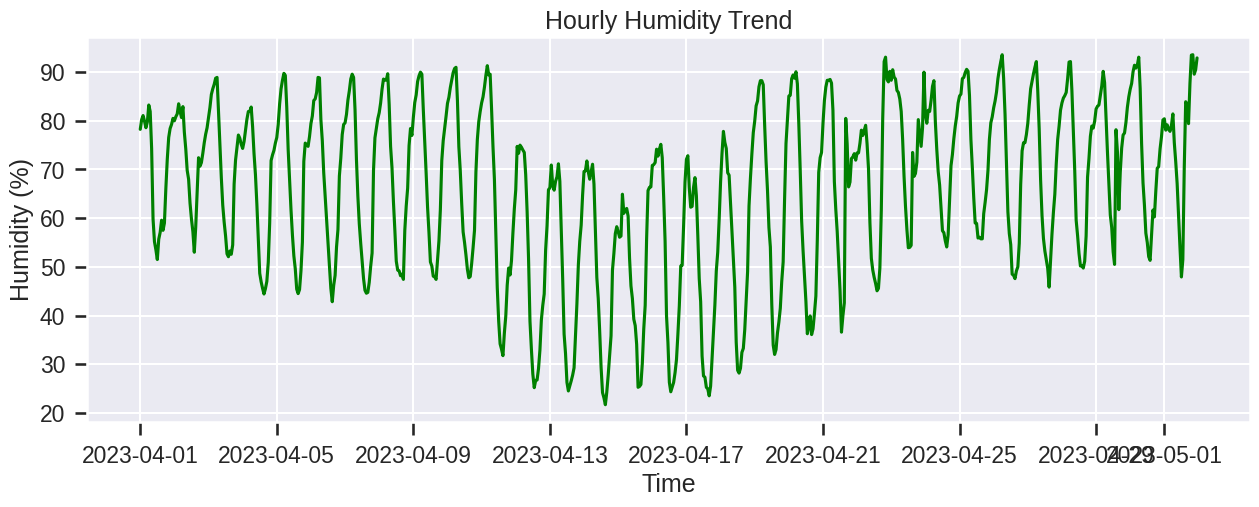

In [24]:
#Humidity
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Humidity (%)"], color="green")
plt.title("Hourly Humidity Trend")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.show()


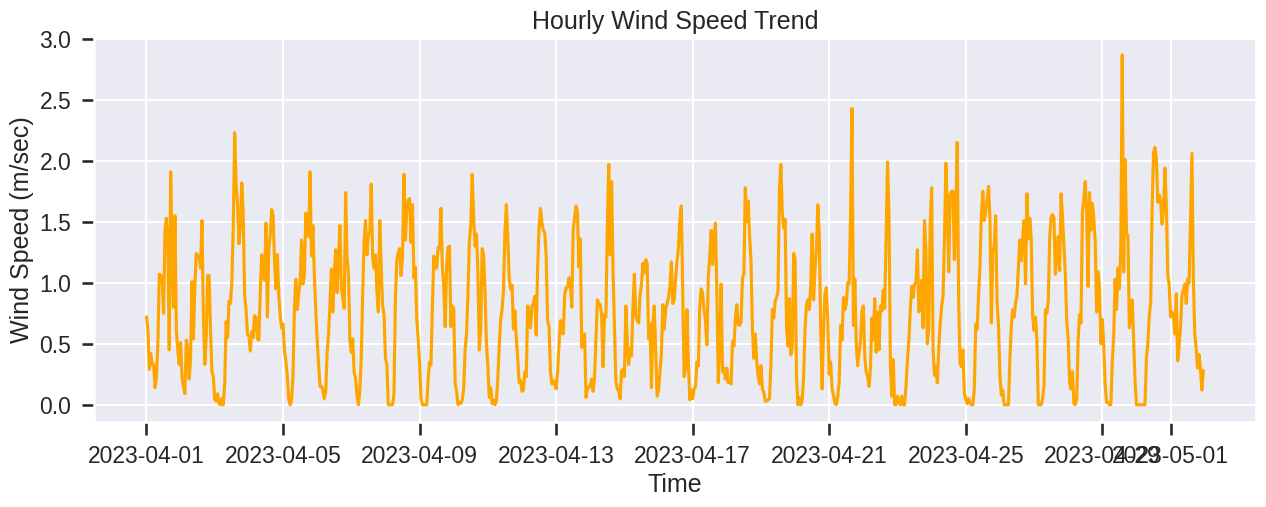

In [25]:

#Wind Speed
plt.figure(figsize=(15,5))
plt.plot(df.index, df["Wind Speed (m/sec)"], color="orange")
plt.title("Hourly Wind Speed Trend")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/sec)")
plt.show()


In [26]:
#DAILY & MONTHLY PATTERNS (AGGREGATION EDA)

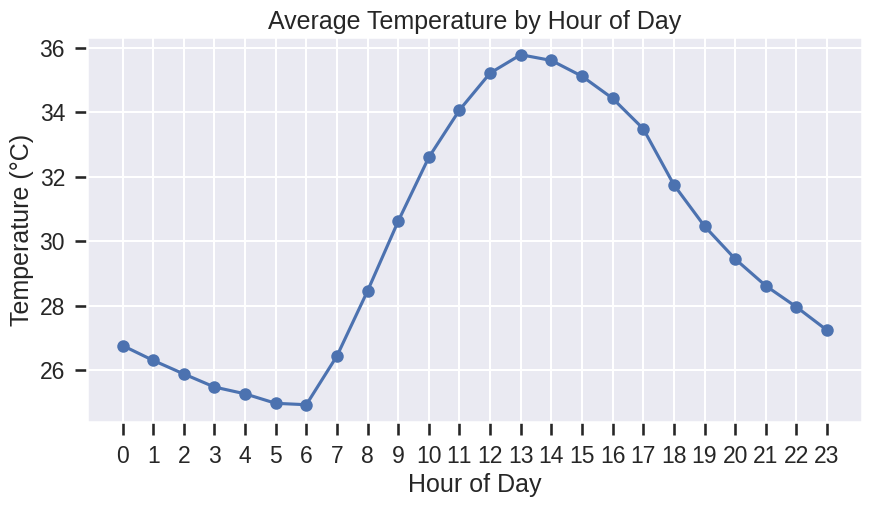

In [27]:
#Average Temperature by Hour of Day
df["Hour"] = df.index.hour

hourly_avg = df.groupby("Hour")["Outdoor Temperature (°C)"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg, marker="o")
plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.xticks(range(0,24))
plt.show()


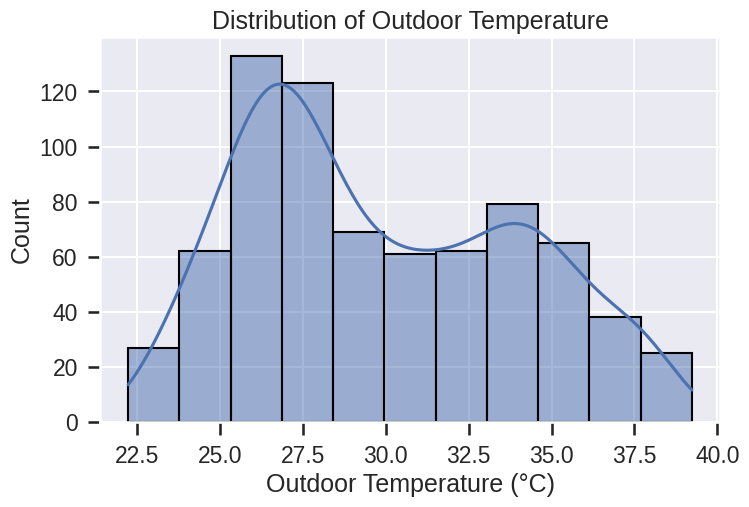

In [28]:
# DISTRIBUTION ANALYSIS (STATISTICAL EDA)
#Temperature Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Outdoor Temperature (°C)"], kde=True)
plt.title("Distribution of Outdoor Temperature")
plt.show()


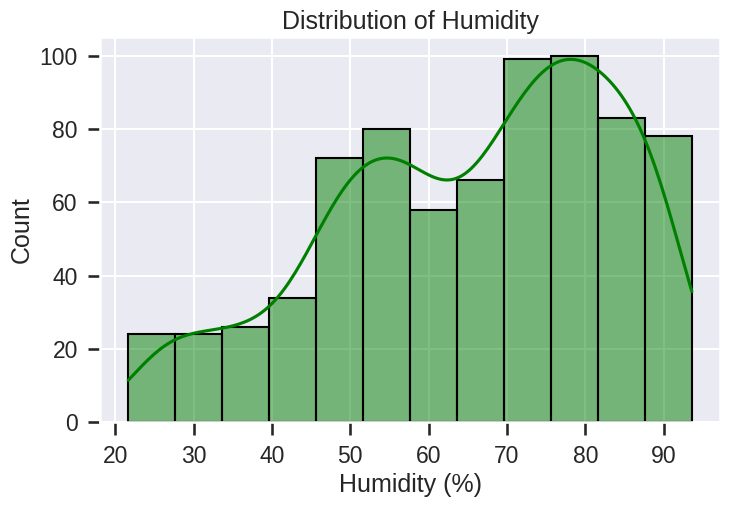

In [29]:
#Temperature Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Humidity (%)"], kde=True, color="green")
plt.title("Distribution of Humidity")
plt.show()


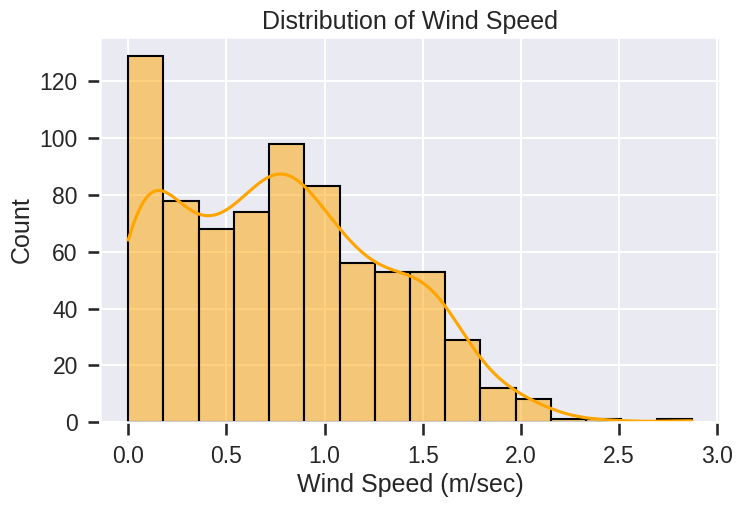

In [30]:
#Wind Speed Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Wind Speed (m/sec)"], kde=True, color="orange")
plt.title("Distribution of Wind Speed")
plt.show()


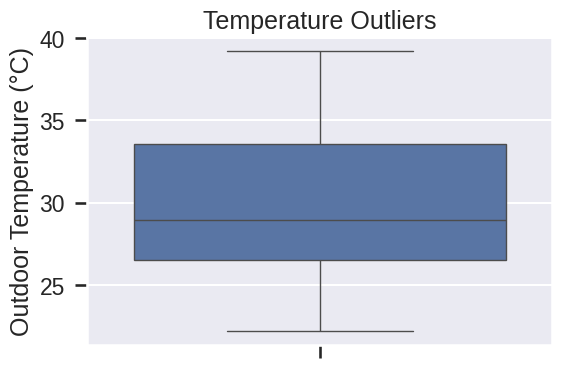

In [31]:
#Temperature Outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Outdoor Temperature (°C)"])
plt.title("Temperature Outliers")
plt.show()


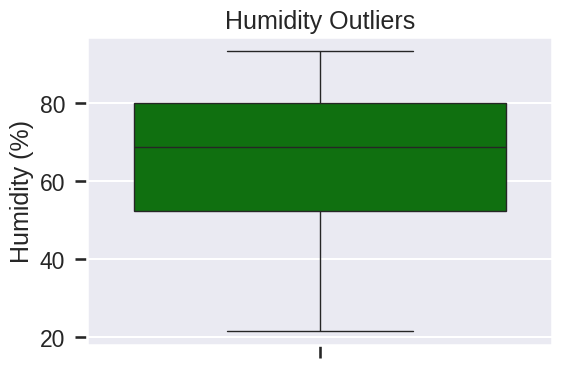

In [32]:
#Humidity Outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Humidity (%)"], color="green")
plt.title("Humidity Outliers")
plt.show()


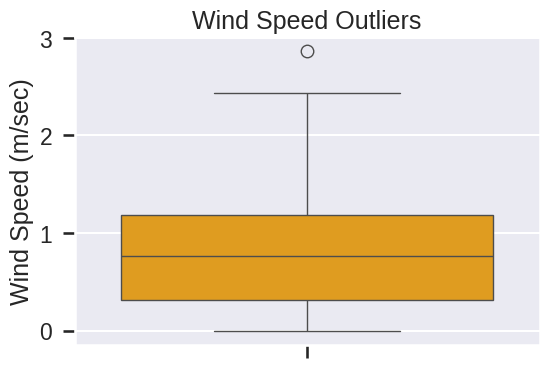

In [33]:
#
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Wind Speed (m/sec)"], color="orange")
plt.title("Wind Speed Outliers")
plt.show()


In [34]:
##ROLLING STATISTICS (ADVANCED TIME-SERIES EDA)

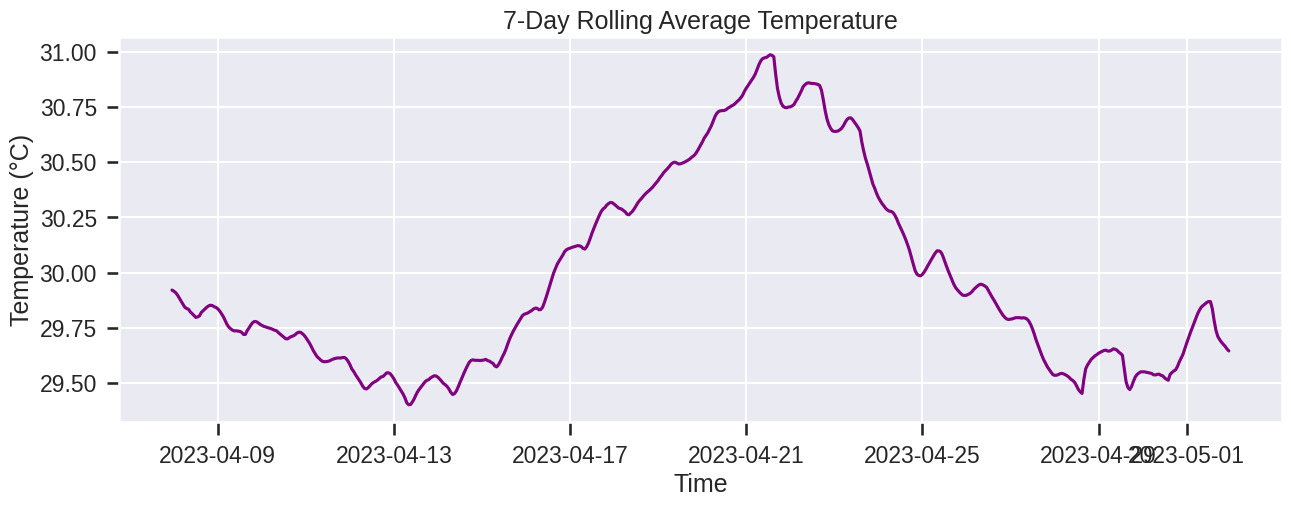

In [35]:

#7-Day Rolling Mean (Temperature)
df["Temp_7D_Rolling"] = df["Outdoor Temperature (°C)"].rolling(24*7).mean()

plt.figure(figsize=(15,5))
plt.plot(df.index, df["Temp_7D_Rolling"], color="purple")
plt.title("7-Day Rolling Average Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()
